# 02 — Baseline-модели

Устанавливаем точку отсчёта для сравнения с более сложными моделями:
1. **Majority class** — всегда предсказывает самый частый класс (H)
2. **Logistic Regression** — линейная модель со стандартизацией

Основная метрика: **Weighted F1-score**

In [1]:
import sys
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.preprocessing import FEATURE_COLS, TARGET_COL
from src.models import evaluate_model, plot_confusion_matrix, results_table

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROC_DIR = Path(ROOT) / "data" / "processed"
MODELS_DIR = Path(ROOT) / "models"
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Библиотеки загружены")

Библиотеки загружены


## 1. Загрузка данных

In [2]:
train = pd.read_csv(PROC_DIR / "train.csv", parse_dates=["date"])
val   = pd.read_csv(PROC_DIR / "val.csv",   parse_dates=["date"])
test  = pd.read_csv(PROC_DIR / "test.csv",  parse_dates=["date"])

print(f"Train : {train.shape}  (сезоны 2017–2021)")
print(f"Val   : {val.shape}    (сезон 2022)")
print(f"Test  : {test.shape}   (сезоны 2023–2024)")

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]

X_val   = val[FEATURE_COLS]
y_val   = val[TARGET_COL]

X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL]

print("\nРаспределение классов в train:")
for code, name in [(2, "H (победа хозяев)"), (1, "D (ничья)"), (0, "A (победа гостей)")]:
    n = (y_train == code).sum()
    print(f"  {name}: {n} ({n/len(y_train)*100:.1f}%)")

Train : (1192, 33)  (сезоны 2017–2021)
Val   : (240, 33)    (сезон 2022)
Test  : (480, 33)   (сезоны 2023–2024)

Распределение классов в train:
  H (победа хозяев): 507 (42.5%)
  D (ничья): 309 (25.9%)
  A (победа гостей): 376 (31.5%)


## 2. Baseline 1 — Majority Class

Простейший baseline: всегда предсказывать наиболее частый класс (победа хозяев).

In [3]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)

print("=== Majority Class Baseline ===")
dummy_val_metrics  = evaluate_model(dummy, X_val,  y_val,  split_name="val")
dummy_test_metrics = evaluate_model(dummy, X_test, y_test, split_name="test")

dummy_val_metrics["model"]  = "Majority Class"
dummy_test_metrics["model"] = "Majority Class"

=== Majority Class Baseline ===

Результаты на val
  Weighted F1 : 0.3014
  Accuracy    : 0.4708
  F1 по классам: A=0.000  D=0.000  H=0.640
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        72
           D       0.00      0.00      0.00        55
           H       0.47      1.00      0.64       113

    accuracy                           0.47       240
   macro avg       0.16      0.33      0.21       240
weighted avg       0.22      0.47      0.30       240


Результаты на test
  Weighted F1 : 0.2793
  Accuracy    : 0.4500
  F1 по классам: A=0.000  D=0.000  H=0.621
              precision    recall  f1-score   support

           A       0.00      0.00      0.00       133
           D       0.00      0.00      0.00       131
           H       0.45      1.00      0.62       216

    accuracy                           0.45       480
   macro avg       0.15      0.33      0.21       480
weighted avg       0.20      0.45      0.28 

## 3. Baseline 2 — Logistic Regression

Линейная модель с предобработкой:
- `StandardScaler` — нормализация признаков
- `LogisticRegression` с multi-class softmax, регуляризация L2
- Fixed seed для воспроизводимости

In [4]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000,
        C=1.0,
        random_state=RANDOM_SEED,
    )),
])

lr_pipeline.fit(X_train, y_train)

print("=== Logistic Regression ===")
lr_val_metrics  = evaluate_model(lr_pipeline, X_val,  y_val,  split_name="val")
lr_test_metrics = evaluate_model(lr_pipeline, X_test, y_test, split_name="test")

lr_val_metrics["model"]  = "Logistic Regression"
lr_test_metrics["model"] = "Logistic Regression"

=== Logistic Regression ===

Результаты на val
  Weighted F1 : 0.4724
  Accuracy    : 0.5375
  F1 по классам: A=0.537  D=0.000  H=0.661
              precision    recall  f1-score   support

           A       0.48      0.61      0.54        72
           D       0.00      0.00      0.00        55
           H       0.59      0.75      0.66       113

    accuracy                           0.54       240
   macro avg       0.36      0.45      0.40       240
weighted avg       0.42      0.54      0.47       240


Результаты на test
  Weighted F1 : 0.4314
  Accuracy    : 0.4979
  F1 по классам: A=0.476  D=0.041  H=0.641
              precision    recall  f1-score   support

           A       0.43      0.53      0.48       133
           D       0.18      0.02      0.04       131
           H       0.55      0.77      0.64       216

    accuracy                           0.50       480
   macro avg       0.39      0.44      0.39       480
weighted avg       0.42      0.50      0.43     

## 4. Матрицы ошибок

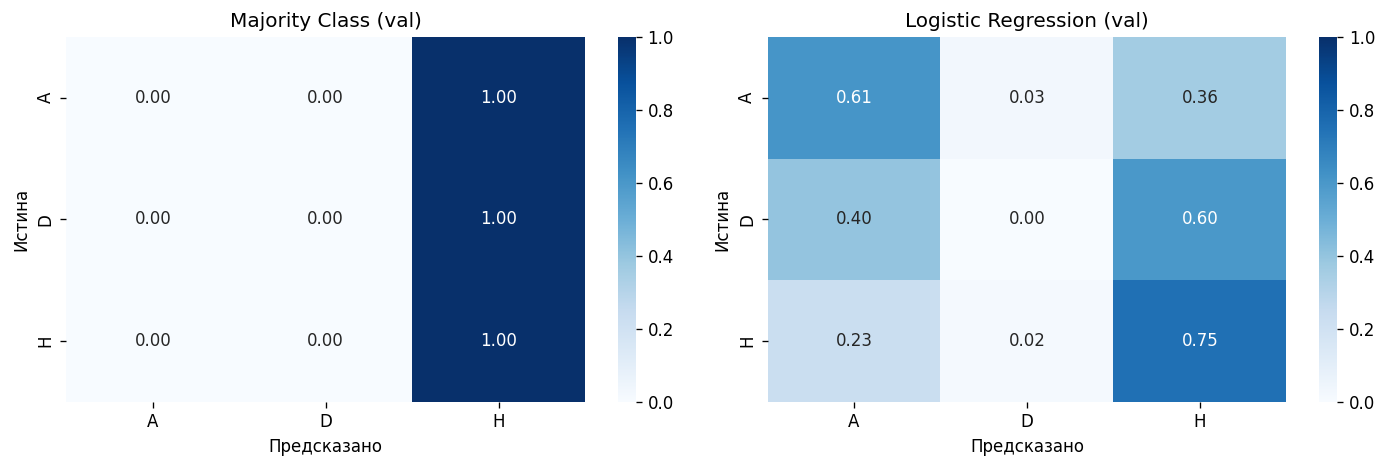

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_confusion_matrix(dummy,       X_val, y_val, title="Majority Class (val)",       ax=axes[0])
plot_confusion_matrix(lr_pipeline, X_val, y_val, title="Logistic Regression (val)",  ax=axes[1])

plt.tight_layout()
plt.show()

## 5. Анализ коэффициентов Logistic Regression

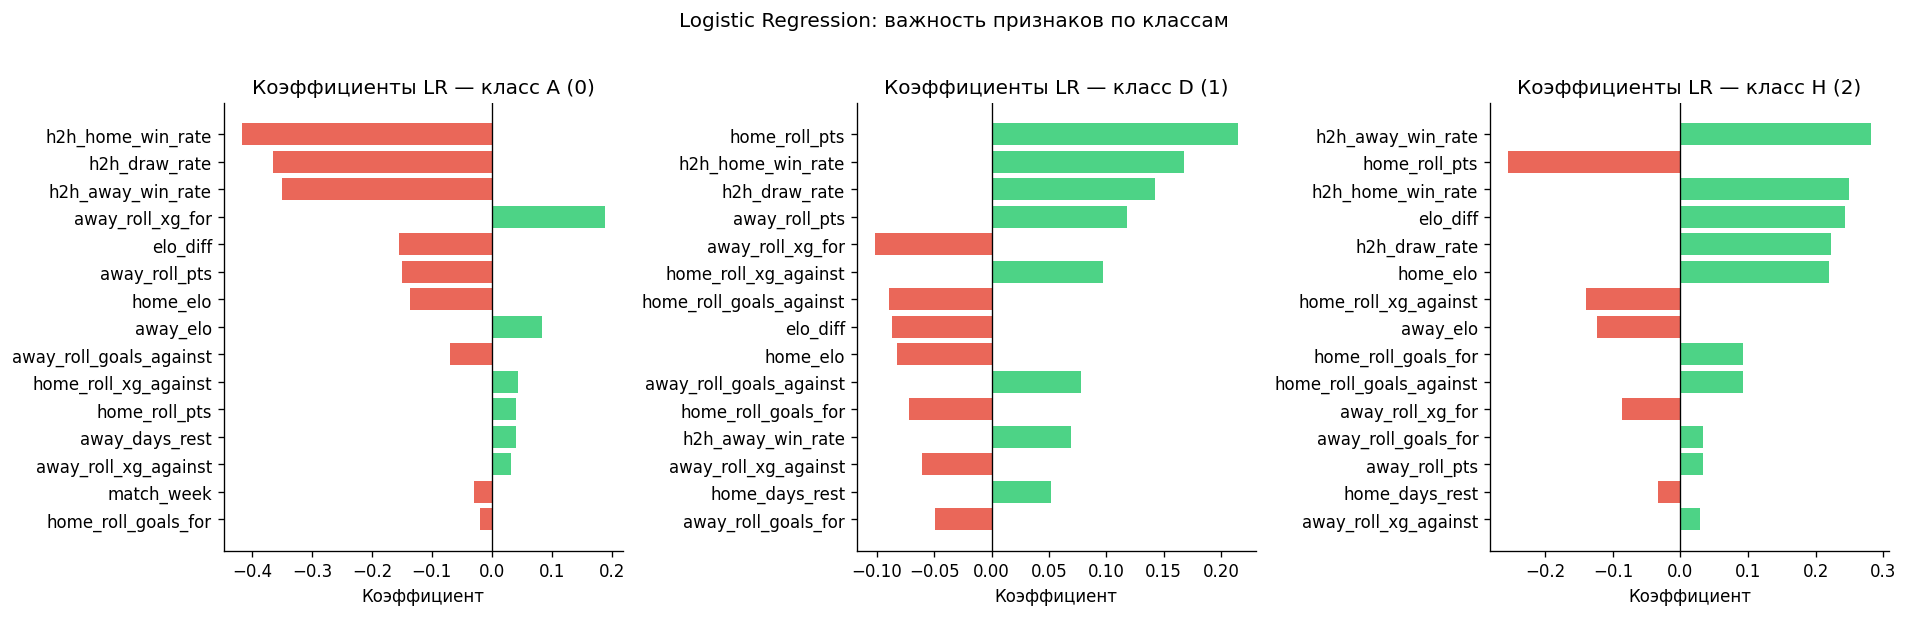

In [6]:
coef = lr_pipeline.named_steps["clf"].coef_
classes = ["A (0)", "D (1)", "H (2)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (ax, cls) in enumerate(zip(axes, classes)):
    idx = np.argsort(np.abs(coef[i]))[-15:]
    ax.barh(
        [FEATURE_COLS[j] for j in idx],
        coef[i][idx],
        color=["#e74c3c" if v < 0 else "#2ecc71" for v in coef[i][idx]],
        alpha=0.85,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Коэффициенты LR — класс {cls}")
    ax.set_xlabel("Коэффициент")

plt.suptitle("Logistic Regression: важность признаков по классам", y=1.02)
plt.tight_layout()
plt.show()

## 6. Сводная таблица результатов

In [7]:
records_val = [
    dummy_val_metrics,
    lr_val_metrics,
]

df_results = results_table(records_val)
cols_show = ["model", "split", "weighted_f1", "accuracy", "f1_A", "f1_D", "f1_H"]
print("Сравнение baseline-моделей (val):")
print(df_results[cols_show].to_string(index=False))

Сравнение baseline-моделей (val):
              model split  weighted_f1  accuracy   f1_A  f1_D   f1_H
     Majority Class   val       0.3014    0.4708 0.0000   0.0 0.6402
Logistic Regression   val       0.4724    0.5375 0.5366   0.0 0.6615


## 7. Вывод

Baseline-результаты:
- **Majority Class** даёт weighted F1 = accuracy ≈ 45% (всегда предсказывает H)
- **Logistic Regression** улучшает метрику — линейная граница уже улавливает часть закономерностей

Оба результата будут использоваться как точка отсчёта в `03_experiments.ipynb`.